# Training MNIST with Gradience
This notebook demonstrates how to train a Multi-Layer Perceptron (MLP) on the classic MNIST handwritten digit dataset using the `Gradience` framework.

In [ ]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

from gradience.tensor import Tensor
from gradience.nn.containers.sequential import Sequential
from gradience.nn.layers.linear import Linear
from gradience.nn.activations.relu import ReLU
from gradience.nn.activations.sigmoid import Sigmoid
from gradience.nn.losses.mse import MSELoss
from gradience.optim.sgd import SGD

## 1. Load and Preprocess the Dataset
We fetch the dataset, normalize pixel values to `[0, 1]`, and one-hot encode the 10 digit classes. We will restrict our training loop to 10,000 samples to keep training times fast for this demonstration.

In [ ]:
print('Fetching MNIST (this may take a moment)...')
mnist = fetch_openml('mnist_784', version=1, parser='auto', as_frame=False)
X, y = mnist['data'], mnist['target']
X = X / 255.0  # Normalize

# Take a subset for rapid testing
num_train = 10000
num_test = 2000
X_train, X_test = X[:num_train], X[num_train:num_train+num_test]
y_train, y_test = y[:num_train], y[num_train:num_train+num_test]

def one_hot(labels, classes=10):
    return np.eye(classes)[labels.astype(int)]

y_train_oh = one_hot(y_train)
y_test_oh = one_hot(y_test)

print(f'Training shape: {X_train.shape}')
print(f'Testing shape: {X_test.shape}')

Fetching MNIST (this may take a moment)...
Training shape: (10000, 784)
Testing shape: (2000, 784)


## 2. Define the Neural Network Architecture
We build a network that takes $784$ input pixels, projects down to a hidden layer of $128$ neurons using a `ReLU` non-linearity, and outputs $10$ predictions passed through a `Sigmoid` to map the results between $0$ and $1$.

In [ ]:
model = Sequential(
    Linear(784, 128),
    ReLU(),
    Linear(128, 10),
    Sigmoid()
)

# Mean Squared Error across the one-hot vectors
criterion = MSELoss()
optimizer = SGD(model.parameters(), lr=1.0) # Relatively high LR since MSE gradient is averaged over batch*10 elements

## 3. Mini-Batch Training Loop
We shuffle our training data and run forward/backward passes in chunks of `64` to speed up convergence.

In [ ]:
epochs = 20
batch_size = 64
train_losses = []
val_losses = []
val_accuracies = []

X_test_tensor = Tensor(X_test)
y_test_tensor = Tensor(y_test_oh)

print('Starting training...')
for epoch in range(epochs):
    model.train() # Set to train mode
    permutation = np.random.permutation(len(X_train))
    epoch_loss = 0.0
    
    for i in range(0, len(X_train), batch_size):
        indices = permutation[i:i+batch_size]
        
        batch_X = Tensor(X_train[indices])
        batch_y = Tensor(y_train_oh[indices])
        
        optimizer.zero_grad()
        preds = model(batch_X)
        loss = criterion(preds, batch_y)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
    avg_train_loss = epoch_loss / (len(X_train) / batch_size)
    train_losses.append(avg_train_loss)

    # Validation phase
    model.eval() # Set to eval mode
    val_preds = model(X_test_tensor)
    val_loss = criterion(val_preds, y_test_tensor).item()
    val_losses.append(val_loss)

    # Calculate val accuracy
    pred_classes = np.argmax(val_preds.numpy(), axis=1)
    true_classes = y_test.astype(int)
    val_acc = np.mean(pred_classes == true_classes)
    val_accuracies.append(val_acc)

    print(f'Epoch {epoch+1:02d}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%')

Starting training...
Epoch 01/20 | Train Loss: 0.0570 | Val Loss: 0.0351 | Val Acc: 84.45%
Epoch 02/20 | Train Loss: 0.0290 | Val Loss: 0.0255 | Val Acc: 89.05%
Epoch 03/20 | Train Loss: 0.0228 | Val Loss: 0.0222 | Val Acc: 89.50%
Epoch 04/20 | Train Loss: 0.0199 | Val Loss: 0.0195 | Val Acc: 90.30%
Epoch 05/20 | Train Loss: 0.0181 | Val Loss: 0.0187 | Val Acc: 91.00%
Epoch 06/20 | Train Loss: 0.0165 | Val Loss: 0.0173 | Val Acc: 91.50%
Epoch 07/20 | Train Loss: 0.0154 | Val Loss: 0.0160 | Val Acc: 92.20%
Epoch 08/20 | Train Loss: 0.0146 | Val Loss: 0.0154 | Val Acc: 92.45%
Epoch 09/20 | Train Loss: 0.0138 | Val Loss: 0.0150 | Val Acc: 92.50%
Epoch 10/20 | Train Loss: 0.0132 | Val Loss: 0.0150 | Val Acc: 92.20%
Epoch 11/20 | Train Loss: 0.0126 | Val Loss: 0.0142 | Val Acc: 92.80%
Epoch 12/20 | Train Loss: 0.0121 | Val Loss: 0.0135 | Val Acc: 92.90%
Epoch 13/20 | Train Loss: 0.0117 | Val Loss: 0.0134 | Val Acc: 92.85%
Epoch 14/20 | Train Loss: 0.0112 | Val Loss: 0.0129 | Val Acc: 93.20%

## 4. Evaluation and Visualization
We will plot the MSE loss curve and calculate the test-set accuracy of our framework!

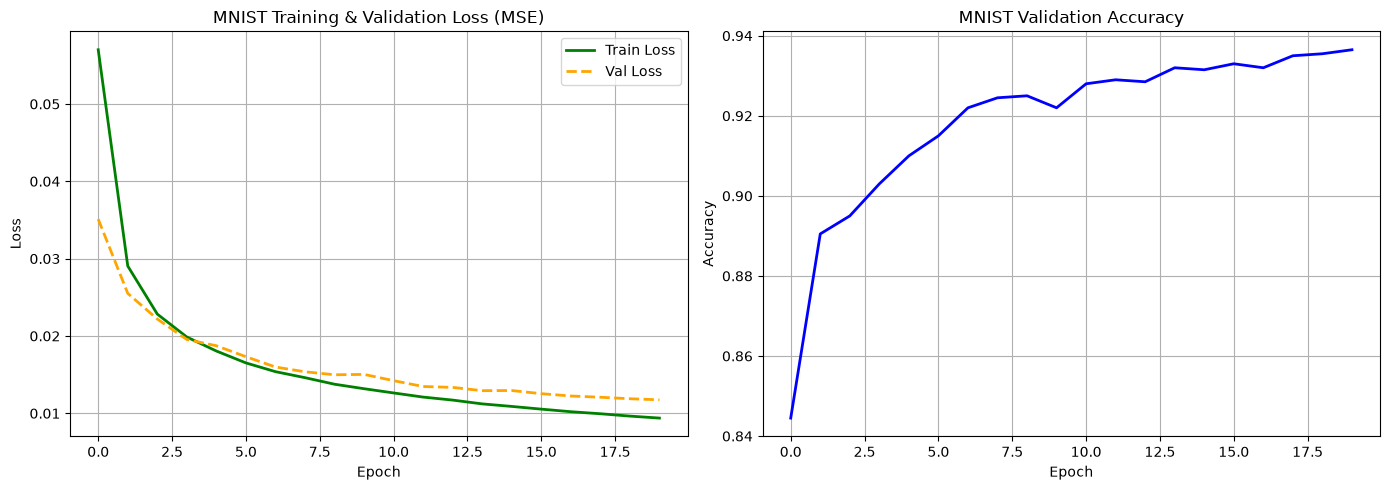

Final Test/Validation Accuracy: 93.65%


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Loss Curves
ax1.plot(train_losses, color='green', linewidth=2, label='Train Loss')
ax1.plot(val_losses, color='orange', linewidth=2, linestyle='--', label='Val Loss')
ax1.set_title('MNIST Training & Validation Loss (MSE)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Plot Validation Accuracy
ax2.plot(val_accuracies, color='blue', linewidth=2)
ax2.set_title('MNIST Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f'Final Test/Validation Accuracy: {val_accuracies[-1] * 100:.2f}%')

## 5. PyTorch Comparison
Let's validate the Gradience training run against PyTorch. We will set up the exact same mini-batch routine.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

pt_model = nn.Sequential(
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 10),
    nn.Sigmoid()
)

pt_criterion = nn.MSELoss()
pt_optimizer = optim.SGD(pt_model.parameters(), lr=1.0)

pt_train_losses = []
pt_val_losses = []
pt_val_accuracies = []

X_test_pt = torch.tensor(X_test, dtype=torch.float32)
y_test_oh_pt = torch.tensor(y_test_oh, dtype=torch.float32)

print('Starting PyTorch training...')
for epoch in range(epochs):
    pt_model.train()
    permutation = np.random.permutation(len(X_train))
    epoch_loss = 0.0
    
    for i in range(0, len(X_train), batch_size):
        indices = permutation[i:i+batch_size]
        
        batch_X = torch.tensor(X_train[indices], dtype=torch.float32)
        batch_y = torch.tensor(y_train_oh[indices], dtype=torch.float32)
        
        pt_optimizer.zero_grad()
        preds = pt_model(batch_X)
        loss = pt_criterion(preds, batch_y)
        loss.backward()
        pt_optimizer.step()
        
        epoch_loss += loss.item()
        
    avg_train_loss = epoch_loss / (len(X_train) / batch_size)
    pt_train_losses.append(avg_train_loss)
    
    # Validation
    pt_model.eval()
    with torch.no_grad():
        val_preds = pt_model(X_test_pt)
        val_loss = pt_criterion(val_preds, y_test_oh_pt).item()
        pt_val_losses.append(val_loss)
        
        pred_classes = torch.argmax(val_preds, dim=1).numpy()
        true_classes = y_test.astype(int)
        val_acc = np.mean(pred_classes == true_classes)
        pt_val_accuracies.append(val_acc)
        
    print(f'Epoch {epoch+1:02d}/{epochs} | PT Train: {avg_train_loss:.4f} | PT Val: {val_loss:.4f} | PT Acc: {val_acc*100:.2f}%')

Starting PyTorch training...
Epoch 01/20 | PT Train: 0.0783 | PT Val: 0.0525 | PT Acc: 65.70%
Epoch 02/20 | PT Train: 0.0420 | PT Val: 0.0347 | PT Acc: 84.35%
Epoch 03/20 | PT Train: 0.0295 | PT Val: 0.0260 | PT Acc: 88.85%
Epoch 04/20 | PT Train: 0.0236 | PT Val: 0.0220 | PT Acc: 89.35%
Epoch 05/20 | PT Train: 0.0207 | PT Val: 0.0198 | PT Acc: 90.45%
Epoch 06/20 | PT Train: 0.0186 | PT Val: 0.0183 | PT Acc: 90.95%
Epoch 07/20 | PT Train: 0.0173 | PT Val: 0.0173 | PT Acc: 91.15%
Epoch 08/20 | PT Train: 0.0163 | PT Val: 0.0165 | PT Acc: 91.45%
Epoch 09/20 | PT Train: 0.0154 | PT Val: 0.0162 | PT Acc: 91.65%
Epoch 10/20 | PT Train: 0.0146 | PT Val: 0.0159 | PT Acc: 91.90%
Epoch 11/20 | PT Train: 0.0140 | PT Val: 0.0149 | PT Acc: 92.20%
Epoch 12/20 | PT Train: 0.0134 | PT Val: 0.0145 | PT Acc: 92.30%
Epoch 13/20 | PT Train: 0.0129 | PT Val: 0.0140 | PT Acc: 92.80%
Epoch 14/20 | PT Train: 0.0124 | PT Val: 0.0135 | PT Acc: 93.00%
Epoch 15/20 | PT Train: 0.0120 | PT Val: 0.0133 | PT Acc: 92.

### Plot Gradience vs PyTorch

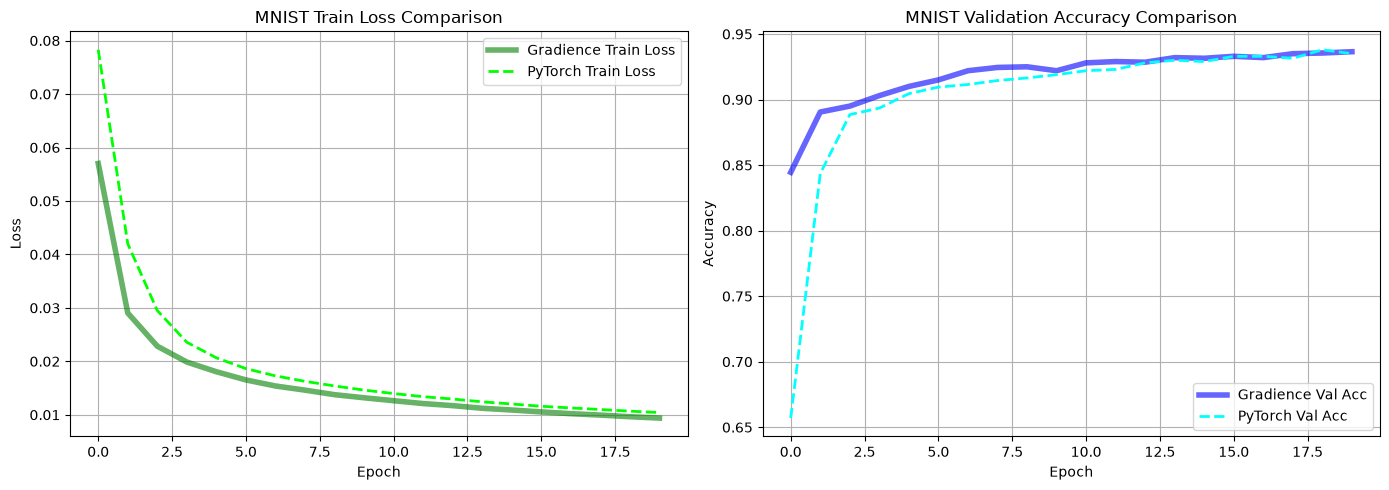

Gradience Final Acc: 93.65%
PyTorch Final Acc:   93.50%


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Train Losses
ax1.plot(train_losses, color='green', linewidth=4, alpha=0.6, label='Gradience Train Loss')
ax1.plot(pt_train_losses, color='lime', linewidth=2, linestyle='--', label='PyTorch Train Loss')
ax1.set_title('MNIST Train Loss Comparison')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Plot Validation Accuracy
ax2.plot(val_accuracies, color='blue', linewidth=4, alpha=0.6, label='Gradience Val Acc')
ax2.plot(pt_val_accuracies, color='cyan', linewidth=2, linestyle='--', label='PyTorch Val Acc')
ax2.set_title('MNIST Validation Accuracy Comparison')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f'Gradience Final Acc: {val_accuracies[-1]*100:.2f}%')
print(f'PyTorch Final Acc:   {pt_val_accuracies[-1]*100:.2f}%')